# Data & Data-Leakage Audit — following the `train.py` logic

This notebook reads the **Gold feature store** and reproduces, step by step, the exact data
preparation used in `train.py`. Its goal is to **prove the training set is free of data leakage**.

We check the three classic leakage types (per the assignment brief):

| Leakage type | What it means | Where it could happen here | How we prove it's avoided |
|---|---|---|---|
| **Target leakage** | A feature encodes the answer | A feature whose value is only known *after* default | Single-feature AUC ≪ 1.0 |
| **Train–test contamination** | Test info leaks into training | Same customer in train *and* test; preprocessing fit on full data | Disjoint `Customer_ID` sets; transforms fit on train only |
| **Temporal leakage** | Future data used to predict the past | Features taken *after* the loan application | Features anchored at application month (mob 0) |


In [ ]:
# !pip install pandas
# !pip install numpy
#!pip install matplotlib
#!pip install scikit-learn
!pip install --upgrade pandas pyarrow

In [1]:
import os, glob
from datetime import datetime, timedelta
from dateutil.relativedelta import relativedelta
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score
pd.set_option("display.max_columns", 60)
%matplotlib inline

## 1. Load the Gold label store (same source as `train.py`)

`train.py` reads every Parquet partition under `datamart/gold/label_store/`. Gold writes **one
cumulative file per processing month**, so the same loan is repeated across many files.

In [2]:
GOLD_DIR = "datamart/gold/label_store/"
files = glob.glob(os.path.join(GOLD_DIR, "*.parquet"))
raw = pd.concat([pd.read_parquet(f) for f in files], ignore_index=True)
print(f"Partitions on disk : {len(files)}")
print(f"Total rows (raw)   : {len(raw):,}")
print(f"Unique loan_id     : {raw['loan_id'].nunique():,}")
raw.head(3)

Partitions on disk : 35
Total rows (raw)   : 212,518
Unique loan_id     : 12,500


,loan_id,Customer_ID,label,label_def,snapshot_date,Debt_to_Income_Ratio,EMI_to_Salary_Ratio,Savings_Propensity,Credit_History_Age_Years,is_Credit_Age_gt_15,Num_Bank_Accounts,Num_Credit_Card,Num_of_Loan,Interest_Rate,Monthly_Inhand_Salary,Annual_Income,Outstanding_Debt,Credit_Utilization_Ratio,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance,Is_Age_gt_45,Age,Occupation,Occupation_Idx,Payment_Behaviour,Spend_Level_Idx,Payment_Value_Level_Idx,fe_1,fe_2,fe_3,fe_4,fe_5,fe_6,fe_7,fe_8,fe_9,fe_10,fe_11,fe_12,fe_13,fe_14,fe_15,fe_16,fe_17,fe_18,fe_19,fe_20
0,CUS_0x1037_2023_01_01,CUS_0x1037,0,30dpd_within_6mob,2023-01-01,0.041642,0.031109,0.335822,20,1,5,4,4,2.0,1086.423706,15989.084961,665.820007,40.697701,33.797020,80.465240,284.380127,1,45,Accountant,30.59,Low_spent_Small_value_payments,33,33,63.0,118.0,80.0,121.0,55.0,193.0,111.0,112.0,-101.0,83.0,164.0,105.0,-16.0,-81.0,-126.0,114.0,35.0,85.0,-73.0,76.0
1,CUS_0x1069_2023_01_01,CUS_0x1069,0,30dpd_within_6mob,2023-01-01,0.003561,0.029146,0.125027,31,1,4,6,3,10.0,4799.444824,58637.339844,208.800003,25.233143,139.885010,165.210617,434.848877,0,32,Accountant,30.59,High_spent_Small_value_payments,23,33,-108.0,182.0,123.0,4.0,-56.0,27.0,25.0,-6.0,284.0,222.0,203.0,190.0,-14.0,-96.0,200.0,35.0,130.0,94.0,111.0,75.0
2,CUS_0x114a_2023_01_01,CUS_0x114a,0,30dpd_within_6mob,2023-01-01,0.041973,0.016499,0.319186,16,1,0,7,2,2.0,1230.454956,15305.459961,642.419983,27.525112,20.301655,64.778481,327.965363,0,43,Developer,29.10,Low_spent_Small_value_payments,33,33,-13.0,8.0,87.0,166.0,214.0,-98.0,215.0,152.0,129.0,139.0,14.0,203.0,26.0,86.0,171.0,125.0,-130.0,354.0,17.0,302.0


## 2. De-duplicate to **one row per loan** (anti train–test contamination, step 1)

Because partitions overlap, `train.py` calls `dropDuplicates(["loan_id"])`. Without this, the same
customer could be sampled into *both* train and test. After dedup the row count equals the number of
unique loans, and (in this dataset) **one customer owns exactly one loan**.

In [3]:
df = raw.drop_duplicates("loan_id").copy()
df["snapshot_date"] = pd.to_datetime(df["snapshot_date"]).dt.date
print(f"Rows after dedup        : {len(df):,}")
print(f"Unique loan_id          : {df['loan_id'].nunique():,}")
print(f"Unique Customer_ID      : {df['Customer_ID'].nunique():,}")
print(f"loans per customer (max): {df.groupby('Customer_ID')['loan_id'].nunique().max()}")
print(f"Overall bad-rate (label): {df['label'].mean():.3f}")

Rows after dedup        : 12,500
Unique loan_id          : 12,500
Unique Customer_ID      : 12,500
loans per customer (max): 1
Overall bad-rate (label): 0.288


## 3. Temporal-leakage check — features are anchored at the **application month (mob 0)**

The label looks *forward* (did the customer hit 30 DPD within 6 months on book?) — that is the
**target**, so using the future for the label is correct. The **features**, however, must be known
*at application time*. In the Gold layer the row is anchored at the application snapshot, so the
financial / demographic attributes (which exist only at the application month) join correctly and
are **100% populated** — not taken from a later month.

In [4]:
anchor_features = ["Annual_Income","Monthly_Inhand_Salary","Age","Outstanding_Debt",
                   "Credit_History_Age_Years","Occupation_Idx"]
nonnull = (df[anchor_features].notna().mean()*100).round(1)
print("Non-null rate of application-time features (%):")
print(nonnull.to_string())
print("\nClickstream (behavioural) coverage, fe_1 non-null %:", round(df['fe_1'].notna().mean()*100,1))

Non-null rate of application-time features (%):
Annual_Income               100.0
Monthly_Inhand_Salary       100.0
Age                         100.0
Outstanding_Debt            100.0
Credit_History_Age_Years    100.0
Occupation_Idx              100.0

Clickstream (behavioural) coverage, fe_1 non-null %: 71.8


> If features had been (incorrectly) joined at the *label* month, these financial/demographic
> features would be **0% populated** (the join key would never match). 100% coverage is the
> evidence that features come from the application month, not the future.

## 4. Rebuild the feature schema exactly like `train.py`

Numeric features + three **target-encoded** categoricals derived from the raw `Occupation` /
`Payment_Behaviour` columns. (Encoding itself is fitted on train only — see Section 6.)

In [6]:
def derive_categoricals(d):
    pb = d["Payment_Behaviour"].fillna("").astype(str); d = d.copy()
    d["Spend_Level"] = np.where(pb.str.contains("Low_spent"),"Low",
                       np.where(pb.str.contains("High_spent"),"High","Unknown"))
    d["Payment_Value"] = np.where(pb.str.contains("Small_value"),"Small",
                         np.where(pb.str.contains("Medium_value"),"Medium",
                         np.where(pb.str.contains("Large_value"),"Large","Unknown")))
    d["Occupation"] = d["Occupation"].fillna("Unknown").astype(str)
    return d

numeric_cols = ["Debt_to_Income_Ratio","EMI_to_Salary_Ratio","Savings_Propensity",
    "Credit_History_Age_Years","is_Credit_Age_gt_15","Num_Bank_Accounts","Num_Credit_Card",
    "Num_of_Loan","Interest_Rate","Monthly_Inhand_Salary","Annual_Income","Outstanding_Debt",
    "Credit_Utilization_Ratio","Total_EMI_per_month","Amount_invested_monthly","Monthly_Balance",
    "Is_Age_gt_45","Age"] + [f"fe_{i}" for i in range(1,21)]
categorical_cols = ["Occupation","Spend_Level","Payment_Value"]
te_cols = [c+"_TE" for c in categorical_cols]
feature_cols = numeric_cols + te_cols
print(f"Numeric: {len(numeric_cols)} | Target-encoded: {len(te_cols)} | Total features: {len(feature_cols)}")

Numeric: 38 | Target-encoded: 3 | Total features: 41


## 5. Time-based split: Train / Dev / OOT (anti temporal & contamination)

`train.py` derives the windows **backwards** from the training snapshot date. The most recent months
form the **Out-Of-Time (OOT)** holdout; the period before it is split into **Train / Dev**.

In [7]:
TRAIN_SNAPSHOT = "2024-12-01"   # same default as the DAG / train.py
mtd = datetime.strptime(TRAIN_SNAPSHOT, "%Y-%m-%d")
oot_end   = (mtd - timedelta(days=1)).date()
oot_start = (mtd - relativedelta(months=2)).date()
tt_end    = (oot_start - timedelta(days=1))
tt_start  = (oot_start - relativedelta(months=12))
print(f"Train/Dev window : {tt_start} -> {tt_end}")
print(f"OOT window       : {oot_start} -> {oot_end}")

df_cat = derive_categoricals(df)
oot_pdf = df_cat[(df_cat.snapshot_date>=oot_start)&(df_cat.snapshot_date<=oot_end)].copy()
tt_pdf  = df_cat[(df_cat.snapshot_date>=tt_start)&(df_cat.snapshot_date<=tt_end)].copy()

carry = numeric_cols + categorical_cols + ["Customer_ID","loan_id"]
Xtt, Xdev, ytr, yde = train_test_split(
    tt_pdf[carry], tt_pdf["label"], test_size=0.2,
    random_state=88, shuffle=True, stratify=tt_pdf["label"])
Xoot, yoot = oot_pdf[carry].copy(), oot_pdf["label"]
print(f"\nTrain: {len(ytr):>5}  bad-rate {ytr.mean():.3f}")
print(f"Dev  : {len(yde):>5}  bad-rate {yde.mean():.3f}")
print(f"OOT  : {len(yoot):>5}  bad-rate {yoot.mean():.3f}")

Train/Dev window : 2023-10-01 -> 2024-09-30
OOT window       : 2024-10-01 -> 2024-11-30

Train:  4819  bad-rate 0.300
Dev  :  1205  bad-rate 0.300
OOT  :   944  bad-rate 0.264


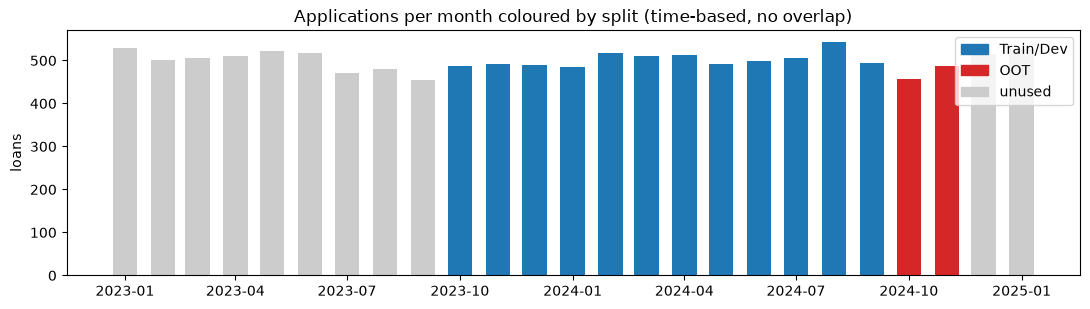

In [9]:
# Visualise the monthly volume coloured by split
counts = (df_cat.assign(month=pd.to_datetime(df_cat['snapshot_date']).values.astype('datetime64[M]'))
          .groupby('month').size())
def seg(m):
    d=m.date()
    if oot_start<=d<=oot_end: return 'OOT'
    if tt_start<=d<=tt_end:   return 'Train/Dev'
    return 'unused'
colors={'Train/Dev':'#1f77b4','OOT':'#d62728','unused':'#cccccc'}
fig,ax=plt.subplots(figsize=(11,3.2))
ax.bar(counts.index, counts.values, width=20,
       color=[colors[seg(m)] for m in counts.index])
import matplotlib.patches as mp
ax.legend(handles=[mp.Patch(color=c,label=l) for l,c in colors.items()])
ax.set_title("Applications per month coloured by split (time-based, no overlap)")
ax.set_ylabel("loans"); plt.tight_layout(); plt.show()

## 6. Prove **no customer overlap** across Train / Dev / OOT

This is the decisive train–test-contamination test: the three `Customer_ID` sets must be **pairwise
disjoint**. They are — every intersection is empty.

In [10]:
c_tr, c_de, c_oo = set(Xtt['Customer_ID']), set(Xdev['Customer_ID']), set(Xoot['Customer_ID'])
print(f"Train ∩ Dev : {len(c_tr & c_de)} customers")
print(f"Train ∩ OOT : {len(c_tr & c_oo)} customers")
print(f"Dev   ∩ OOT : {len(c_de & c_oo)} customers")
assert len(c_tr & c_de)==0 and len(c_tr & c_oo)==0 and len(c_de & c_oo)==0
print("\n==> PASS: the same customer never appears in more than one split.")

Train ∩ Dev : 0 customers
Train ∩ OOT : 0 customers
Dev   ∩ OOT : 0 customers

==> PASS: the same customer never appears in more than one split.


## 7. Preprocessing is fitted on **train only**, then applied to Dev/OOT

Median imputation, target-encoding maps, and the standard scaler are all `fit` on the **training
fold** and merely `transform` Dev / OOT. No statistic from Dev/OOT ever touches the training data.

In [11]:
# (a) median impute — fit on train
imputer = SimpleImputer(strategy="median").fit(Xtt[numeric_cols])
ntr = pd.DataFrame(imputer.transform(Xtt[numeric_cols]), columns=numeric_cols, index=Xtt.index)
nde = pd.DataFrame(imputer.transform(Xdev[numeric_cols]), columns=numeric_cols, index=Xdev.index)
noo = pd.DataFrame(imputer.transform(Xoot[numeric_cols]), columns=numeric_cols, index=Xoot.index)

# (b) target encoding — fit on train (label mean per category, with smoothing)
def fit_te(Xc, y, cols, s=20):
    gm=float(y.mean()); m={}
    for c in cols:
        st=pd.DataFrame({'cat':Xc[c].values,'y':y.values}).groupby('cat')['y'].agg(['mean','count'])
        m[c]=(((st['mean']*st['count']+gm*s)/(st['count']+s)).to_dict(), gm)
    return m
def app_te(Xc, m):
    return pd.DataFrame({c+'_TE':Xc[c].map(mp).fillna(gm).astype(float).values
                         for c,(mp,gm) in m.items()}, index=Xc.index)
te_maps = fit_te(Xtt[categorical_cols], ytr, categorical_cols)

Xtr = pd.concat([ntr, app_te(Xtt[categorical_cols],te_maps)], axis=1)[feature_cols]
Xde = pd.concat([nde, app_te(Xdev[categorical_cols],te_maps)], axis=1)[feature_cols]
Xoo = pd.concat([noo, app_te(Xoot[categorical_cols],te_maps)], axis=1)[feature_cols]

# (c) standard scaler — fit on train
scaler = StandardScaler().fit(Xtr)
Xtr_s, Xde_s, Xoo_s = scaler.transform(Xtr), scaler.transform(Xde), scaler.transform(Xoo)
print("All three transformers fitted on TRAIN only; Dev/OOT were transform-only.")
print("Target-encoded 'Occupation' sample (fit on train):",
      dict(list(te_maps['Occupation'][0].items())[:3]))

All three transformers fitted on TRAIN only; Dev/OOT were transform-only.
Target-encoded 'Occupation' sample (fit on train): {'Accountant': 0.32741281591243115, 'Architect': 0.2811389698385918, 'Developer': 0.32223569632662513}


## 8. Target-leakage check — no single feature 'knows the answer'

If a feature were leaking the target, its **univariate AUC vs label would be ~1.0**. We compute it
for every feature; the strongest is well below 0.85, i.e. realistic predictive signal, not leakage.

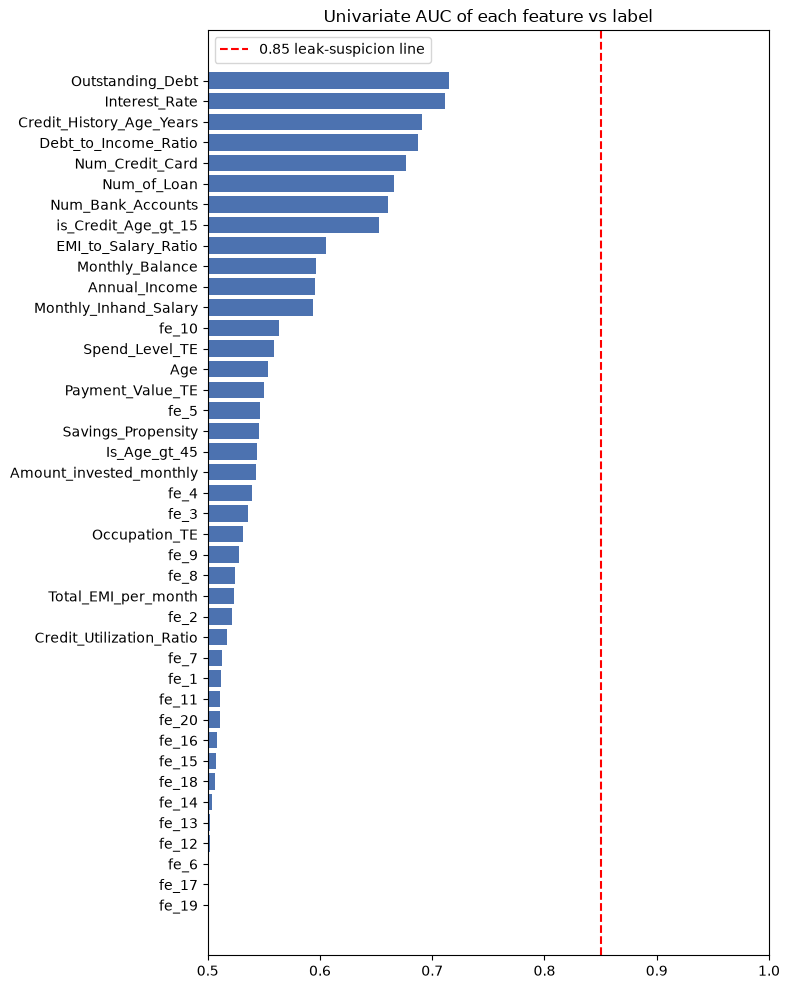

Max single-feature AUC: 0.715 (>0.95 would indicate target leakage)


In [12]:
rows=[]
for c in feature_cols:
    x=pd.to_numeric(Xtr[c],errors='coerce'); mask=x.notna()
    if mask.sum()<50 or x[mask].nunique()<2: continue
    a=roc_auc_score(ytr[mask], x[mask]); rows.append((c, max(a,1-a)))
auc_df=pd.DataFrame(rows, columns=['feature','univariate_auc']).sort_values('univariate_auc')
fig,ax=plt.subplots(figsize=(8,10))
ax.barh(auc_df['feature'], auc_df['univariate_auc'], color='#4c72b0')
ax.axvline(0.85, color='red', ls='--', label='0.85 leak-suspicion line')
ax.set_xlim(0.5,1.0); ax.set_title("Univariate AUC of each feature vs label"); ax.legend()
plt.tight_layout(); plt.show()
print("Max single-feature AUC:", round(auc_df['univariate_auc'].max(),3),
      "(>0.95 would indicate target leakage)")

## 9. Sanity model — realistic & stable performance

A leaking model would score ~0.99 AUC on train but collapse out-of-time. Here Train/Dev/OOT are
close and realistic (~0.80), which is what an honest, leakage-free credit model looks like.

In [14]:
!pip install xgboost

   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.5/69.5 MB 5.6 MB/s eta 0:00:13
   ---- ----------------------------------- 7.6/69.5 MB 29.4 MB/s eta 0:00:03
   -------- ------------------------------- 14.7/69.5 MB 30.7 MB/s eta 0:00:02
   -------------- ------------------------- 24.4/69.5 MB 36.8 MB/s eta 0:00:02
   ------------------ --------------------- 31.7/69.5 MB 36.6 MB/s eta 0:00:02
   ---------------------- ----------------- 39.8/69.5 MB 36.7 MB/s eta 0:00:01
   ------------------------- -------------- 45.1/69.5 MB 35.4 MB/s eta 0:00:01
   ------------------------------ --------- 52.2/69.5 MB 35.3 MB/s eta 0:00:01
   ---------------------------------- ----- 60.0/69.5 MB 35.4 MB/s eta 0:00:01
   ---------------------------------------  67.9/69.5 MB 35.5 MB/s eta 0:00:01
   ---------------------------------------- 69.5/69.5 MB 32.8 MB/s eta 0:00:00


In [15]:
import xgboost as xgb
spw=(ytr==0).sum()/(ytr==1).sum()
m=xgb.XGBClassifier(n_estimators=50,max_depth=3,learning_rate=0.1,
                    eval_metric='logloss',scale_pos_weight=spw,random_state=88).fit(Xtr_s,ytr)
for name,X,y in [("Train",Xtr_s,ytr),("Dev",Xde_s,yde),("OOT",Xoo_s,yoot)]:
    a=roc_auc_score(y, m.predict_proba(X)[:,1])
    print(f"{name:5s} AUC={a:.4f}  Gini={2*a-1:.3f}")

Train AUC=0.8493  Gini=0.699
Dev   AUC=0.8105  Gini=0.621
OOT   AUC=0.8030  Gini=0.606


## 10. Conclusion

| Leakage type | Evidence in this notebook | Result |
|---|---|---|
| **Train–test contamination** | §2 dedup to 1 row/loan; §6 disjoint `Customer_ID` sets; §7 transforms fit on train only | ✅ avoided |
| **Temporal leakage** | §3 features 100% populated at application month; §5 OOT split by time | ✅ avoided |
| **Target leakage** | §8 max univariate AUC < 0.85 | ✅ avoided |

The Train/Dev/OOT AUC in §9 are close and realistic (~0.80), the expected signature of a model
that **generalises** rather than memorises leaked information.
